# Detecção de Discurso de Ódio em Português com BERT
Este notebook aplica o modelo pré-treinado **BERTimbau** (`neuralmind/bert-base-portuguese-cased`), treinado em corpus de português brasileiro, para classificação de discurso de ódio usando a base **HateBR**. BERT é a abordagem de maior complexidade no estudo comparativo, utilizando representações contextuais de texto.

**Configurações padronizadas entre todos os modelos:**
- Dataset: HateBR (carregado via GitHub)
- Split: 80% treino / 20% teste, com `stratify=y` e `random_state=42`
- Pré-processamento: não aplicado (BERT utiliza o tokenizador WordPiece nativo)
- Métrica principal: F1-score macro

## 1. Importações

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print('PyTorch version:', torch.__version__)
print('GPU disponível:', torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Usando:', device)

/home/heliocm/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-19 00:34:40.507835: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


PyTorch version: 2.7.1+cu126
GPU disponível: False
Usando: cpu


## 2. Carregamento da base de dados
A base HateBR é carregada diretamente do repositório no GitHub. Contém 7.000 comentários em português com rótulo binário: `1` = discurso de ódio, `0` = não ódio.

In [2]:
url = 'https://raw.githubusercontent.com/franciellevargas/HateBR/refs/heads/main/dataset/HateBR.csv'
df = pd.read_csv(url)

print(f'Total de amostras: {len(df)}')
print(f'Distribuição de classes:\n{df["label_final"].value_counts()}')
df[['comentario', 'label_final']].head()

Total de amostras: 7000
Distribuição de classes:
label_final
1    3500
0    3500
Name: count, dtype: int64


,comentario,label_final
0,Mais um lixo,1
1,Essa nao tem vergonha na cara!!,1
2,Essa mulher é doente.pilantra!,1
3,Comunista safada...,1
4,Vagabunda. Comunista. Mentirosa. O povo chilen...,1


## 3. Divisão treino/teste
Split 80/20 com `stratify=y` para garantir proporção balanceada de classes nos dois conjuntos.

> **Nota:** Para BERT não aplicamos pré-processamento manual — o tokenizador WordPiece do modelo lida com capitalização, pontuação e subwords nativamente.

In [3]:
train_df, test_df = train_test_split(
    df[['comentario', 'label_final']],
    test_size=0.2,
    random_state=42,
    stratify=df['label_final']
)

train_df = train_df.rename(columns={'comentario': 'text', 'label_final': 'labels'})
test_df  = test_df.rename(columns={'comentario': 'text', 'label_final': 'labels'})

print(f'Treinamento: {len(train_df)} amostras')
print(f'Teste:       {len(test_df)} amostras')

Treinamento: 5600 amostras
Teste:       1400 amostras


## 4. Tokenização com BERTimbau
Usamos `AutoTokenizer` do `neuralmind/bert-base-portuguese-cased`, com truncamento em `max_length=128` (abrange >95% dos textos do HateBR).

In [4]:
MODEL_NAME = 'neuralmind/bert-base-portuguese-cased'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=128
    )

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df.reset_index(drop=True))

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print('Tokenização concluída.')
print('Colunas:', train_dataset.column_names)

Map: 100%|██████████| 1400/1400 [00:00<00:00, 43204.30 examples/s]

Tokenização concluída.
Colunas: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


## 5. Carregamento do modelo
`AutoModelForSequenceClassification` com `num_labels=2` inicializa a cabeça de classificação sobre o encoder BERT pré-treinado.

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
print('Modelo carregado.')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Modelo carregado.


## 6. Função de métricas
Calculamos F1-score macro durante o treinamento para monitorar a generalização em ambas as classes.

In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    f1_macro = f1_score(labels, predictions, average='macro')
    accuracy = (predictions == labels).mean()
    return {
        'f1_macro': f1_macro,
        'accuracy': accuracy
    }

## 7. Configuração e treinamento
Usamos `evaluation_strategy='epoch'` e `save_strategy='epoch'` para avaliação a cada época e salvamento do melhor checkpoint (`load_best_model_at_end=True`).

In [7]:
training_args = TrainingArguments(
    output_dir='./bert_hatebr_checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',     # Avaliação a cada época
    save_strategy='epoch',           # Salva checkpoint a cada época
    load_best_model_at_end=True,     # Carrega o melhor ao final
    metric_for_best_model='f1_macro',
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir='./bert_hatebr_logs',
    logging_steps=50,
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

/tmp/ipykernel_181103/3992026250.py:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/home/heliocm/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.227500,0.253130,0.910707,0.910714
2,0.222600,0.324082,0.906426,0.906429
3,0.072200,0.396002,0.912827,0.912857


/home/heliocm/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/heliocm/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=1050, training_loss=0.18406633694966634, metrics={'train_runtime': 1725.4879, 'train_samples_per_second': 9.736, 'train_steps_per_second': 0.609, 'total_flos': 648379640391360.0, 'train_loss': 0.18406633694966634, 'epoch': 3.0})

## 8. Salvamento do modelo final

In [8]:
model.save_pretrained('./bert_hatebr_final')
tokenizer.save_pretrained('./bert_hatebr_final')
print('Modelo salvo em ./bert_hatebr_final')

Modelo salvo em ./bert_hatebr_final


## 9. Avaliação no conjunto de teste
Métricas: precisão, recall, **F1-score macro** (métrica principal do estudo) e matriz de confusão.

/home/heliocm/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


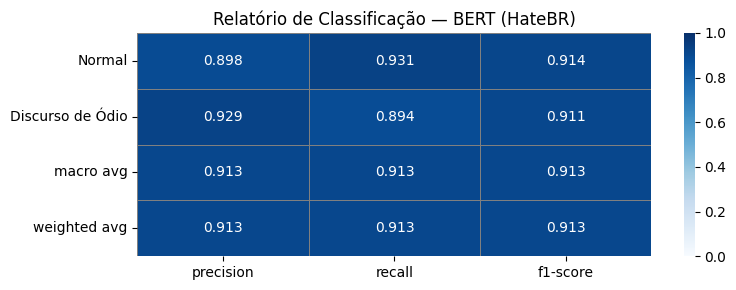

F1-score Macro: 0.9128


In [9]:
predictions_output = trainer.predict(test_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_test = test_df['labels'].values

# Relatório de classificação como imagem
report_dict = classification_report(y_test, y_pred, target_names=['Normal', 'Discurso de Ódio'], output_dict=True)
df_report = pd.DataFrame(report_dict).T.drop('accuracy', errors='ignore')

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    df_report[['precision', 'recall', 'f1-score']].astype(float),
    annot=True, fmt='.3f', cmap='Blues',
    linewidths=0.5, linecolor='gray',
    ax=ax, vmin=0, vmax=1
)
ax.set_title('Relatório de Classificação \u2014 BERT (HateBR)')
plt.tight_layout()
plt.savefig('report_bert_hatebr.png', dpi=150, bbox_inches='tight')
plt.show()

f1_macro = report_dict['macro avg']['f1-score']
print(f'F1-score Macro: {f1_macro:.4f}')

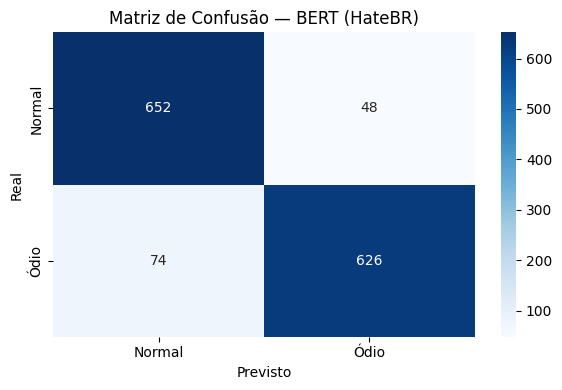

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Ódio'],
            yticklabels=['Normal', 'Ódio'])
plt.title('Matriz de Confusão — BERT (HateBR)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## 10. Métricas por época
Visualizamos a evolução do F1-macro ao longo do treinamento para analisar convergência e possível overfitting.

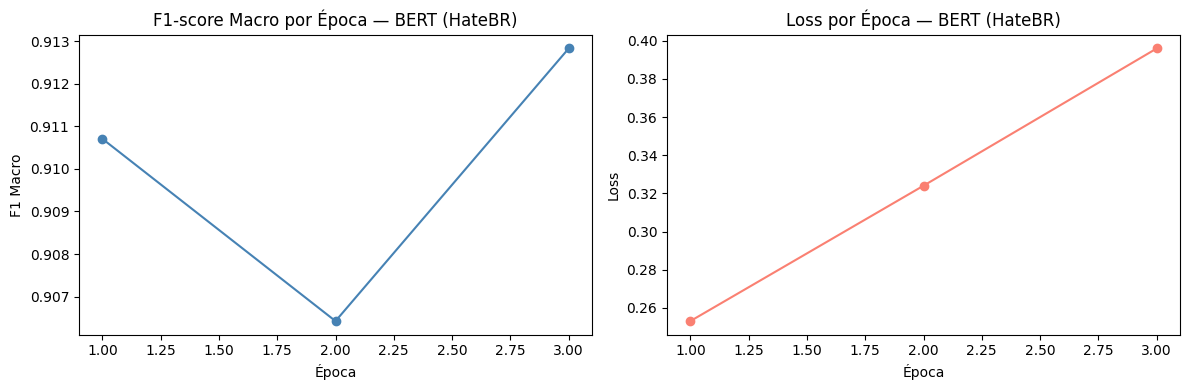

In [14]:
log_history = trainer.state.log_history
eval_entries = [e for e in log_history if 'eval_f1_macro' in e]

if eval_entries:
    epochs = [e['epoch'] for e in eval_entries]
    f1s = [e['eval_f1_macro'] for e in eval_entries]
    losses = [e['eval_loss'] for e in eval_entries]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, f1s, marker='o', color='steelblue')
    axes[0].set_title('F1-score Macro por Época — BERT (HateBR)')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('F1 Macro')

    axes[1].plot(epochs, losses, marker='o', color='salmon')
    axes[1].set_title('Loss por Época — BERT (HateBR)')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')

    plt.tight_layout()
    plt.show()
else:
    print('Histórico de avaliação não disponível.')

In [12]:
# ANALISE_QUALITATIVA_PATCH
import pandas as _pd, numpy as _np, os as _os

# Textos de teste já disponíveis em test_df
_texts = test_df['text'].values

# Índices de FP e FN
_fp_idx = _np.where((y_test == 0) & (y_pred == 1))[0]
_fn_idx = _np.where((y_test == 1) & (y_pred == 0))[0]

_rng = _np.random.default_rng(42)
_fp_s = _rng.choice(_fp_idx, size=min(10, len(_fp_idx)), replace=False) if len(_fp_idx) else _np.array([], int)
_fn_s = _rng.choice(_fn_idx, size=min(10, len(_fn_idx)), replace=False) if len(_fn_idx) else _np.array([], int)

_rows = []
for _i in _fp_s:
    _rows.append({'modelo': 'BERTimbau', 'dataset': 'HateBR',
                   'tipo': 'Falso Positivo', 'texto': _texts[_i],
                   'rotulo_real': int(y_test[_i]), 'predicao': int(y_pred[_i])})
for _i in _fn_s:
    _rows.append({'modelo': 'BERTimbau', 'dataset': 'HateBR',
                   'tipo': 'Falso Negativo', 'texto': _texts[_i],
                   'rotulo_real': int(y_test[_i]), 'predicao': int(y_pred[_i])})

_csv = 'analisequalitativa.csv'
_df_new = _pd.DataFrame(_rows)
if _os.path.exists(_csv):
    _df_existing = _pd.read_csv(_csv)
    # Remove entradas anteriores do mesmo modelo/dataset antes de adicionar
    _df_existing = _df_existing[
        ~((_df_existing['modelo'] == 'BERTimbau') & (_df_existing['dataset'] == 'HateBR'))
    ]
    _df_new = _pd.concat([_df_existing, _df_new], ignore_index=True)
_df_new.to_csv(_csv, index=False)

# Também expõe _texts para a célula de gráfico (se houver)
texts_qualitativa = _texts

print(f'Exportados {len(_fp_s)} FP e {len(_fn_s)} FN → {_csv}')
print(f'Total no arquivo: {len(_df_new)} linhas')

Exportados 10 FP e 10 FN → analisequalitativa.csv
Total no arquivo: 60 linhas
